# Production et analyse des données


In [1]:
import pandas as pd

import os #pour naviguer dans les dossiers
from io import StringIO
import s3fs #pour connecter au bucket
import scipy.stats

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:


# Create filesystem object
S3_ENDPOINT_URL = "https://" + os.environ["AWS_S3_ENDPOINT"]
fs = s3fs.S3FileSystem(client_kwargs={'endpoint_url': S3_ENDPOINT_URL})

BUCKET_OUT = "aluneau"



In [3]:
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-07-24.csv", "r") as file_in:
    df0 = pd.read_csv(file_in, sep =",")

list_affil = pd.read_csv("../list_affiliation.csv", sep =",")
df0 = df0.loc[~df0.q45_clé.isin(["9EAP-NB4B","QNYZ-3MH2"])].merge(list_affil, on = ["q45_clé", "q44_ufr_labo"], how = "left")

In [4]:

df_col = pd.read_csv("../../le_questionnaire/dico_variable.csv", sep = ",")


In [5]:
list_nominal_simple = [x for x in df_col.label.loc[(df_col.type.isin(["simple_nominal", "booléen","ordinal"]))]]


In [6]:
def split_multiple_choices(data, column, index, sep = '|'):
    """
    split and explode column with multiple value

    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_split = data.copy()
    df_split[column]= df_split.apply(lambda row: row[column].replace(";","|") ,1 )
    df_split[column] = df_split[column].str.split(sep)
    df_explode = df_split.explode(column)
    gb_data = df_explode.groupby([column]).agg(nb = (index, "size")).sort_values("nb", ascending=False).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100
    
    return df_explode, gb_data
    

In [7]:
def grouped_question(data, column, index = "q45_clé"):
    """


    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_tmp = data.copy()
    gb_data = df_tmp.groupby([column]).agg(nb = (index, "size")).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100

    return gb_data

In [8]:
def tab_croise(data, x, y, regroup_y = True, khideux = False) :
    """
    x = variable en ligne
    y = variable en colonne
    """
    if regroup_y == True:

        data.loc[data[y].str.lower().str.contains("oui"), f"{y}_rec"] = "Oui"
        data.loc[data[y].str.lower().str.contains("non"), f"{y}_rec"] = "Non"

        cross_tab = pd.crosstab(data[x], data[f"{y}_rec"], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[f"{y}_rec"], margins = False)
    else:
        cross_tab = pd.crosstab(data[x], data[y], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[y], margins = False, normalize=False)

    if khideux == True:
        print(scipy.stats.chi2_contingency(cross_tab0))
        st_chi2, st_p, st_dof, st_exp = scipy.stats.chi2_contingency(cross_tab0)
        chi2 = pd.DataFrame(data={"stats":["chi2","df","p-value"], "values":[st_chi2, st_dof, st_p]})
        cross_tab = pd.concat([cross_tab, chi2])
    else:
        pass

    return cross_tab.fillna("").reset_index(), cross_tab0

In [9]:
df_col["question_family"] = df_col.label.apply(lambda row : row.split("_")[0])

dict_question = dict(zip(df_col.label.loc[df_col.label.isin(list_nominal_simple)], df_col.question_family.loc[df_col.label.isin(list_nominal_simple)]))



## Types de données produites

Les personnes interrogées travaillant exclusivement avec des données dites "quantitatives" sont minoritaires ({numref}`quali_or_quanti`), près de la moitié s'appuient essentiellement sur des données qualitatives et environ un tiers manipulent les deux types de données.

```{table} Données qualitatives ou quantitatives ?
:name: quali_or_quanti

|                           |   nb |    freq |
|:--------------------------|-----:|--------:|
| Des données qualitatives  |   57 | 47,9 |
| Des données quantitatives |   19 | 16,0 |
| Les deux                  |   43 | 36,1 |
|Total               |119   | 100,0|
```

Les quatre types de données les plus fréquemment produites ({numref}`type_donnee_quali`)sont les entretiens, les données textuelles, les données d'enquête et les données expérimentales ou d'observation. On notera toutefois le caractère ambigü de certaines catégories. Ainsi la notion d'"enquête" est largement utilisé en sciences sociales pour désigner la partie empirique des recherche et peut renvoyer aussi bien aux méthodes d'enquêtes ethnographiques qu'aux méthodes d'enquêtes par questionnaire. De même, les données d'observation peuvent se comprendre au sens de l'anthropologue qui observe les interactions au sein d'un groupe humain  ou de l'ornithologue qui compte les espèces d'oiseau. Parmi les "autres types de données", une personne a d'ailleurs précisé qu'il s'agissait d "observations in situ non expérimentales". Tandis qu'une autre ne se reconnait pas dans la notion de "donnée".


```{figure} ./viz/type_donnee_quali.png
:name: type_donnee_quali

Les types de données traitées
```


In [10]:
quali_or_quanti = grouped_question(df0, column="q11_quali_or_quanti", index = "q45_clé")
print(quali_or_quanti[["q11_quali_or_quanti","nb","freq"]].to_markdown(index=False))


df_exp, type_data = split_multiple_choices(df0, column="q10_type_data", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", type_data.to_markdown())

| q11_quali_or_quanti       |   nb |    freq |
|:--------------------------|-----:|--------:|
| Des données qualitatives  |   57 | 47.8992 |
| Des données quantitatives |   19 | 15.9664 |
| Les deux                  |   43 | 36.1345 |

### Dépôt dans Octaviana détaillé 
 |    | q10_type_data                           |   nb |   total |     freq |   total_freq |
|---:|:----------------------------------------|-----:|--------:|---------:|-------------:|
|  0 | Données d'entretien                     |   73 |     119 | 61.3445  |          100 |
|  1 | Données textuelles ou documentaires     |   69 |     119 | 57.9832  |          100 |
|  2 | Données d'enquête                       |   63 |     119 | 52.9412  |          100 |
|  3 | Données expérimentales ou d'observation |   62 |     119 | 52.1008  |          100 |
|  4 | Données statistiques                    |   47 |     119 | 39.4958  |          100 |
|  5 | Données multimédia                      |   22 |     119 | 18.4874  |        

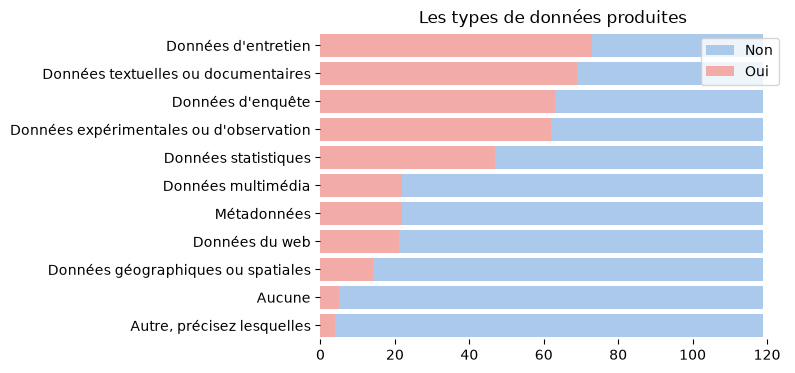

In [11]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")

col= "q10_type_data"
df_exp, gb_data = split_multiple_choices(df0, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/type_donnee.png", bbox_inches='tight', dpi = 200)

In [12]:
col= "q10_type_data"
df_exp, gb_data = split_multiple_choices(df0, column=col, index="q45_clé", sep = '|')
df_exp.q10_type_data

0      Données expérimentales ou d'observation
0                          Données d'entretien
0          Données textuelles ou documentaires
0                           Données multimédia
1                                  Métadonnées
                        ...                   
117                             Données du web
117                       Données statistiques
117                         Données multimédia
118    Données expérimentales ou d'observation
118        Données textuelles ou documentaires
Name: q10_type_data, Length: 402, dtype: object

In [13]:
cross_tab, cross_tab0 = tab_croise(df_exp,  "q10_type_data", "q11_quali_or_quanti", regroup_y = False, khideux = False)
q10 = cross_tab0.cumsum(axis=1).stack().reset_index(name='nb').sort_values(by=["nb", "q11_quali_or_quanti"],  ascending=[False, False])
cross_tab.sort_values(by=["Total"],  ascending=[False])

q11_quali_or_quanti,q10_type_data,Des données qualitatives,Des données quantitatives,Les deux,Total
11,Total,174,49,179,402
3,Données d'entretien,36,8,29,73
9,Données textuelles ou documentaires,43,2,24,69
2,Données d'enquête,32,9,22,63
5,Données expérimentales ou d'observation,25,14,23,62
8,Données statistiques,7,10,30,47
7,Données multimédia,9,1,12,22
10,Métadonnées,5,1,16,22
4,Données du web,7,1,13,21
6,Données géographiques ou spatiales,7,1,6,14


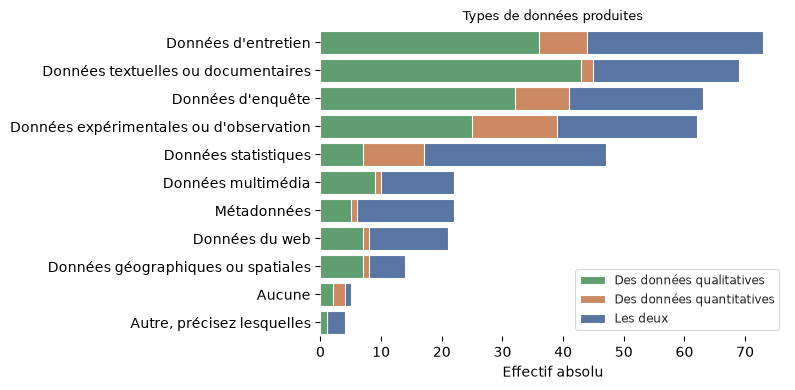

In [14]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(style="ticks", context="paper")

   
g = sns.barplot(x="nb", y="q10_type_data", data=q10, hue="q11_quali_or_quanti", dodge=False)

titre = "Types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set(xlabel='Effectif absolu')
#ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))

handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0]

#add legend to plot

ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])



sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/type_donnee_quali.png", bbox_inches='tight', dpi = 200)

## Autres types de données

In [17]:
for x in df0.q10_other_type_data.loc[~df0.q10_other_type_data.isna()]:
    print(x)

Observations in situ non expérimentales
Images
données orales, multimodales et visuo-gestuelles
pourquoi ce terme de "données" hérité des sciences dures et qui ne recoupe pas le travail dans la plupart des humanités ou dont je n'ai pas envie de me servir pour décrire ma recherche + désambiguisez tous les acronymes cf TGIR


In [18]:
i=-1
for x in df_col.label.loc[(df_col.question_family=="q5")& ((~df_col.label.str.contains("q5_1"))&(~df_col.label.str.contains("rec"))&(~df_col.label.str.contains("family")))]:
    i+=1
    gb_data0 = grouped_question(df0, column=x, index = "q45_clé")
    gb_data = gb_data0.loc[gb_data0[x]=="Oui"]
    gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
    
    if i == 0:
        gb_q5 = gb_data.drop(columns=[x])#.copy()
    else:
        gb_q5 = pd.concat([gb_q5, gb_data.drop(columns=[x])])


/tmp/ipykernel_54511/2686485856.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
/tmp/ipykernel_54511/2686485856.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
/tmp/ipykernel_54511/2686485856.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

## Outils de traitement



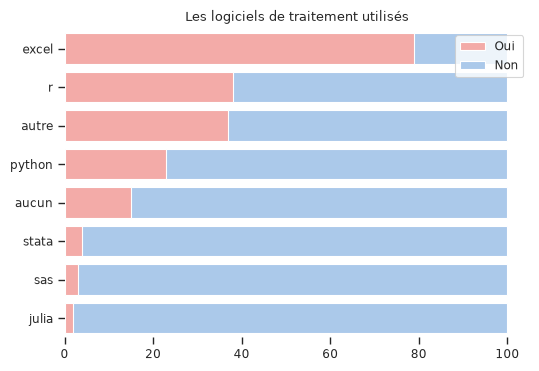

In [19]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")

col = "logiciel_traitement"
sns.barplot(x="total_freq", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="freq", color="r", ax=ax)
titre = "Les logiciels de traitement utilisés"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))

handles, labels = plt.gca().get_legend_handles_labels()
order = [1,0]

#add legend to plot

ax.legend([handles[idx] for idx in order],["Oui","Non"])
    

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/logiciel_traitement.png", bbox_inches='tight', dpi = 200)

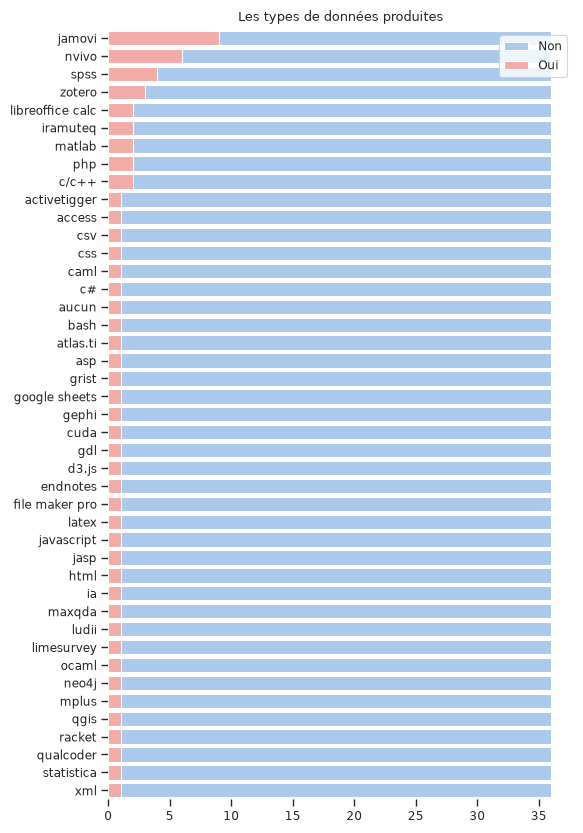

In [20]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,10))

# Plot the total crashes
sns.set_color_codes("pastel")

q5_1 = df0.loc[~df0.q5_1_other_lang_rec.isna()]
col= "q5_1_other_lang_rec"
df_exp, gb_data = split_multiple_choices(q5_1, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
#plt.savefig(f"viz/type_donnee.png", bbox_inches='tight', dpi = 200)

In [21]:
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/type_of_software.csv", "r") as file_in:
    type_logi = pd.read_csv(file_in, sep=",")

type_logi.columns
family_logi = dict(zip(type_logi.q5_logiciel_traitement_rec, type_logi.q5_family_logi))

In [22]:

df_exp, gb_data = split_multiple_choices(df0.loc[~df0.q5_logiciel_traitement_rec.isna()], column='q5_logiciel_traitement_rec', index="q45_clé", sep = '|')

df_exp["q5_family_logi"]= df_exp.q5_logiciel_traitement_rec.map(family_logi.get)
df_exp2 = df_exp.loc[~df_exp.q5_logiciel_traitement_rec.isin(["aucun","autre"])]
df_exp2

,Unnamed: 0,qno_obs,q1_so_principles,q2_hal_depot,q3_octavi_depot,q4_diff_data,q4_autres_entrepots,q5_r,q5_python,q5_excel,...,q16_network_analysis_help,q16_odette_atom_help,q16_caqdas_help,q16_carto_help,q16_sig_help,q16_sgbd_help,q16_autre_help,q16_1_other_software_help,q26_1_autre_rec,q35_ia_tools_rec
2,2,3,"Oui, tout à fait","Oui, plusieurs fois",Je ne connais pas Octaviana,Non,NaN,Non,Non,Oui,...,Non,Non,"Oui, débutant",Non,Non,Non,"Oui, débutant",Logiciel de traitement d'entretiens et de vidéos,NaN,chatgpt|mistral|notebooklm
2,2,3,"Oui, tout à fait","Oui, plusieurs fois",Je ne connais pas Octaviana,Non,NaN,Non,Non,Oui,...,Non,Non,"Oui, débutant",Non,Non,Non,"Oui, débutant",Logiciel de traitement d'entretiens et de vidéos,NaN,chatgpt|mistral|notebooklm
2,2,3,"Oui, tout à fait","Oui, plusieurs fois",Je ne connais pas Octaviana,Non,NaN,Non,Non,Oui,...,Non,Non,"Oui, débutant",Non,Non,Non,"Oui, débutant",Logiciel de traitement d'entretiens et de vidéos,NaN,chatgpt|mistral|notebooklm
2,2,3,"Oui, tout à fait","Oui, plusieurs fois",Je ne connais pas Octaviana,Non,NaN,Non,Non,Oui,...,Non,Non,"Oui, débutant",Non,Non,Non,"Oui, débutant",Logiciel de traitement d'entretiens et de vidéos,NaN,chatgpt|mistral|notebooklm
3,3,4,"Oui, un peu","Oui, une fois",Non,"Autre, précisez",OSF,Oui,Non,Non,...,Non,Non,Non,Non,Non,Non,Non,NaN,NaN,chatgpt|euria
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,115,118,"Oui, un peu","Oui, systématiquement",Non,Non,NaN,Oui,Non,Oui,...,"Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant",Non,NaN,Bibliothèque|Où je peux,claude|chatgpt
116,116,119,"Oui, un peu","Oui, plusieurs fois",Non,Non,NaN,Oui,Non,Oui,...,"Oui, débutant",Non,Non,Non,"Oui, avancé","Oui, débutant",Non,NaN,NaN,NaN
116,116,119,"Oui, un peu","Oui, plusieurs fois",Non,Non,NaN,Oui,Non,Oui,...,"Oui, débutant",Non,Non,Non,"Oui, avancé","Oui, débutant",Non,NaN,NaN,NaN
117,117,120,Non,"Oui, plusieurs fois",Non;Je ne connais pas Octaviana,"Autre, précisez",Mendeley data,Non,Oui,Oui,...,"Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant","Oui, débutant","Oui, avancé","Oui, débutant",​-,NaN,correcteurs d'orthographe


In [23]:
gb_data = df_exp2.groupby(["q5_family_logi", "q5_logiciel_traitement_rec"]).agg(nb=("q45_clé","size")).sort_values(["q5_family_logi","nb"], ascending=[False,False]).reset_index()

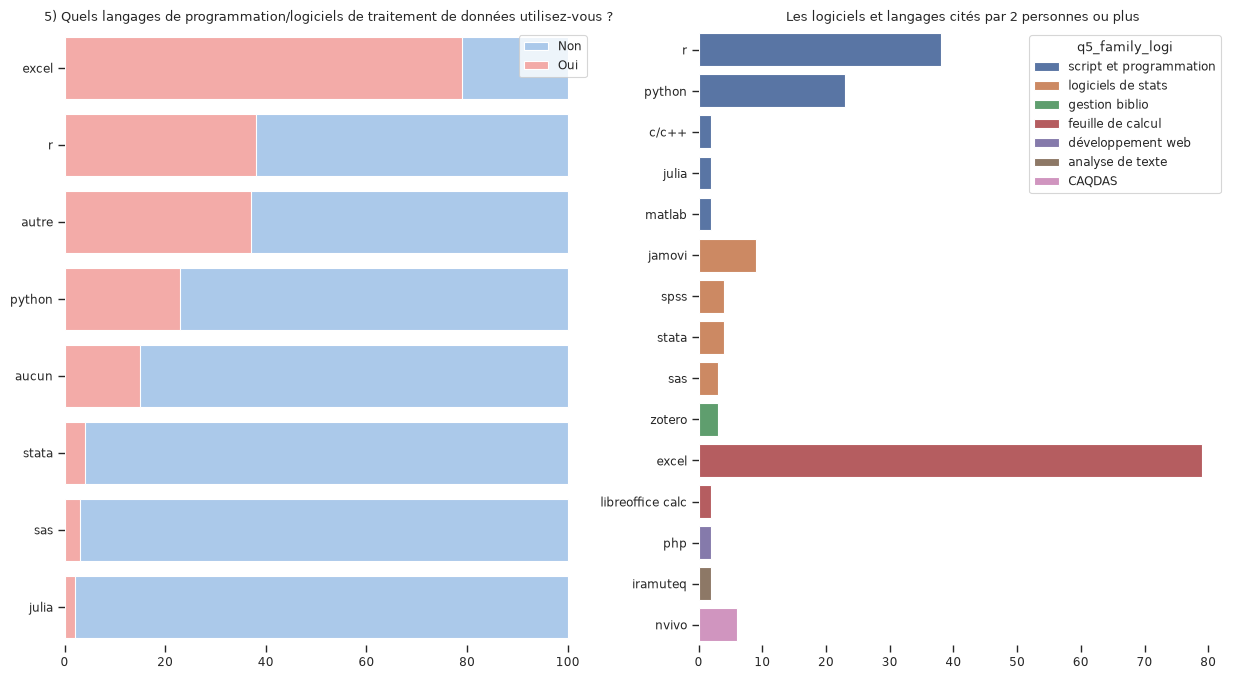

In [24]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, 2, figsize=(15,8))

# Plot the total crashes
sns.set_color_codes("pastel")


col = "logiciel_traitement"
sns.barplot(x="total_freq", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Non", color="b", ax=ax[0])
sns.barplot(x="nb", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Oui", color="r", ax=ax[0])
titre = "5) Quels langages de programmation/logiciels de traitement de données utilisez-vous ?"
ax[0].yaxis.set_label_text("")
ax[0].xaxis.set_label_text("")
ax[0].set_title(titre.replace("<i>","(").replace("</i>",")"))


gb_data2 = gb_data.loc[gb_data.nb>1]
sns.barplot(x="nb", y="q5_logiciel_traitement_rec", data=gb_data2,
            hue="q5_family_logi", ax=ax[1])
titre = "Les logiciels et langages cités par 2 personnes ou plus"
ax[1].yaxis.set_label_text("")
ax[1].xaxis.set_label_text("")
ax[1].set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/logiciel_traitement_use_by_2people.png", bbox_inches='tight', dpi = 200)

Le graphique ci-dessous ({numref}`logiciel_traitement_use_by_2people`) donne à voir les logiciels qui sont cités par plus de deux répondants. Il regroupe les questions 5 et 5.1 sur les logiciels et langages utilisés pour le traitement des données. La question 5 proposait 6 outils : Excel, R, python, SAS, Stata et Julia. Pour chacun de ces outils, les personnes interrogées devaient répondre si elles les utilisaient ou non. Avec la question 5.1, elles pouvaient ensuite compléter leur réponse en donnant le nom d'autres outils informatiques. Les 36 personnes qui ont répondu à la question 5.1 ont ainsi cité 26 autres logiciels et langages, ce qui fait au total 48  outils informatiques différents. Pour faciliter la lecture, nous les avons regroupés par "familles". On retrouve ainsi :

* les "logiciels de statistiques" comme SPSS, Jamovi, Stata ;
* les langages de "scripts et de programmations" comme R, Python, Matlab ou C++. Probablement qu'une subdivision de cette catégorie serait justifiée afin de distinguer les langages généralement employés pour l'analyse de données (R, Julia, Matlab, Python) et les langages de programmation comme C++ ;
* les outils de gestion de bibliographie (Zotero, Endnote) ;
* les logiciels de "tableurs" et les feuilles de calculs : Excel, Libre Calc ;
* les langages liés au développement web (css, html, php, javascript) ;
* les outils d'analyse textuelle (Iramuteq, ActiveTigger) ;
* les "CAQDAS" (Computer-Assisted Qualitative Data Analysis Software) comme Nvivo, Qualcoder, Atlas.ti

En termes d'utilisateurs, Excel est l'outil le plus répendu. Deux tiers des répondants (N=79) y recourent pour traiter leurs données. Ce sont ensuite les langage R (N=38) et Python (N=23) qui sont les plus utilisés. Jamovi (N=9) est le plus cité des logiciels d'analyse statistique, comme Nvivo (N=6) pour les logiciels CAQDAS. On note par ailleurs qu'une peronne sur cinq dit n'utiliser aucun outil informatique pour traiter les données.

```{figure} ./viz/logiciel_traitement_use_by_2people.png
:name: logiciel_traitement_use_by_2people

Logiciels cités par plus de deux répondants
```




## Développement et dépôt de codes ou de logiciels

In [25]:
dev_code= grouped_question(df0, column="q6_dev_code", index = "q45_clé")
print(dev_code)

df_exp, sw_depot2 = split_multiple_choices(df0, column="q7_software_depot", index="q45_clé", sep = '|')
print("\n### Ouverture du code \n", sw_depot2.to_markdown())

  q6_dev_code  nb  total       freq  total_freq
0         Non  87    119  73.109244       100.0
1         Oui  32    119  26.890756       100.0

### Ouverture du code 
 |    | q7_software_depot          |   nb |   total |      freq |   total_freq |
|---:|:---------------------------|-----:|--------:|----------:|-------------:|
|  0 | Non                        |   89 |     119 | 74.7899   |          100 |
|  1 | Oui, sur GitHub            |   23 |     119 | 19.3277   |          100 |
|  2 | Oui, sur GitLab            |   12 |     119 | 10.084    |          100 |
|  3 | Oui, autre, précisez       |    6 |     119 |  5.04202  |          100 |
|  4 | Oui, sur Software Heritage |    1 |     119 |  0.840336 |          100 |


Parallèlement  à l'utilisation d'outils informatiques pour le traitement des données, près d'un quart des répondants ont déjà été amenés à développer ou faire développer du code ou des logiciels dans le cadre de leurs recherches, dont deux n'ont jamais déposé leur code ou logiciel sur un entrepot dédié.

Si le dépôt de code sur Github et Gitlab restent les solutions les plus usitées, 6 personnes déposent leus codes et logiciels ailleurs : 
* "Sur les dépôts SSC des commandes Stata";
* "sur des repositories personnels";
* "sur Hal";
* "sur Ortolang et Huma-Num",
* "Sur des instances auto-hébergées de Gitlab"
* ou "sur l'INPI".


Sur les 32 personnes ayant répondu "Oui" à la question "êtes-vous amené.e à développer ou faire développer des logiciels/du code spécialisé(s) ?", 31 ont donnée des indications plus ou moins précises sur ce qu'elles développent ou font développer en répondant à la question 16 ({numref}`dev_code_tab`). Nous avons analysé les réponses manuellement. On a ainsi 8 personnes qui disent développer des "logiciels variés", des "algorithmes" ou encore des "plateformes, programmes logiciels, œuvres" sans données d'autres précisions. Les chercheurs qui manipulent du code afin de traiter et d'analyser les données constituent le groupe le plus importants (N=14). On observe enfin un petit groupe de personnes (N=7) construisant des outils liés à la collecte de données d'expérience via des jeux ou le logiciel Psytoolkit. 

```{table} Types de code développé
:name: dev_code_tab

| Type de développement                  |   nb |   total |   freq |
|:---------------------------------|-----:|--------:|-------:|
| traitement et analyse de données |   15 |      31 |   48,4 |
| programmes et logiciels variés   |    8 |      31 |   25,8 |
| collecte de données              |    7 |      31 |   22,6 |
| diffusion                        |    2 |      31 |    6,5 |
```


In [26]:
df_exp, gb_data1 = split_multiple_choices(df0.loc[~df0.q6_1_dev_group.isna()], column='q6_1_dev_group', index="q45_clé", sep = '|')
print(gb_data1.drop(columns=["total_freq"]).round(decimals=1).to_markdown(index=False))

| q6_1_dev_group                   |   nb |   total |   freq |
|:---------------------------------|-----:|--------:|-------:|
| traitement et analyse de données |   15 |      31 |   48.4 |
| programmes et logiciels variés   |    8 |      31 |   25.8 |
| collecte de données              |    7 |      31 |   22.6 |
| diffusion                        |    2 |      31 |    6.5 |


## Accompagnements et formations méthodologiques

### Méthodes

In [27]:
for col in df_col.label.loc[(df_col.group=="10_help_methode")&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q18_stat_desc_help   |   nb |   total |    freq |   total_freq |
|---:|:---------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                  |   89 |     119 | 74.7899 |          100 |
|  1 | Oui, avancé          |   16 |     119 | 13.4454 |          100 |
|  2 | Oui, débutant        |   14 |     119 | 11.7647 |          100 |
|    | q18_regressions_help   |   nb |   total |    freq |   total_freq |
|---:|:-----------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                    |   84 |     119 | 70.5882 |          100 |
|  1 | Oui, avancé            |   15 |     119 | 12.605  |          100 |
|  2 | Oui, débutant          |   20 |     119 | 16.8067 |          100 |
|    | q18_temporal_analysis_help   |   nb |   total |    freq |   total_freq |
|---:|:-----------------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                          |   81 |     119 | 68.0672 |          100 |
|  1 | Oui, avancé            

In [28]:
[col for col in df_col.label.loc[(df_col.group=="10_help_methode")&(df_col.type=="ordinal")]]

['q18_stat_desc_help',
 'q18_regressions_help',
 'q18_temporal_analysis_help',
 'q18_cartographie_help',
 'q18_analyse_text_help',
 'q18_net_analysis_help',
 'q18_webscrapping',
 'q18_deeplearning_help',
 'q18_edit_num_help',
 'q18_questionnaire_help',
 'q18_bibliométrie_help']

In [29]:
dict_help_methode = {
    'q18_stat_desc_help':'Statistiques descriptives',
    'q18_regressions_help':'Régression',
 'q18_temporal_analysis_help':'Analyse de données temporelles',
 'q18_cartographie_help': 'Cartographie',
 'q18_analyse_text_help':'Analyse textuelle',
 'q18_net_analysis_help': 'Analyse de réseaux',
 'q18_webscrapping' : 'Webscrapping',
 'q18_deeplearning_help': 'Intelligence artificielle',
 'q18_edit_num_help': 'Edition numérique',
 'q18_questionnaire_help':"Construction d'un questionnaire",
 'q18_bibliométrie_help':'Bibliométrie'}

In [30]:

i=-1
for col in df_col.label.loc[(df_col.group=="10_help_methode")&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_help_methode[col]


    if i == 0:
        q18 = dftmp.copy()
    else:
        q18 = pd.concat([q18, dftmp])


In [31]:
q18_bis = pd.crosstab(q18.accomp_name, q18.interet_accomp, normalize="index").cumsum(axis=1).stack().reset_index(name='nb').sort_values(by=["accomp_name","interet_accomp"],
                                                                                                                                     ascending=[True, False])


In [32]:
for x in q18_bis.accomp_name.unique():
    non = q18_bis.nb.loc[(q18_bis.accomp_name==x) & (q18_bis.interet_accomp=="Non")]
    q18_bis.loc[q18_bis.accomp_name==x, "Non"] = [x for x in non][0]
q18_bis = q18_bis.sort_values(["Non","accomp_name","interet_accomp"],  ascending=[True, False, False])


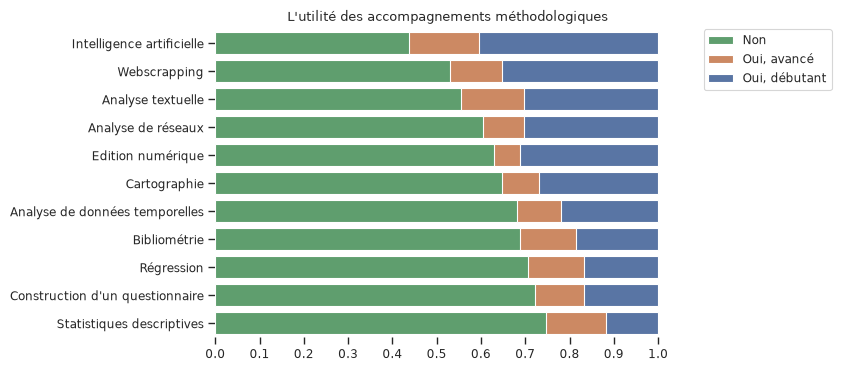

In [35]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(style="ticks", context="paper")

   
g = sns.barplot(x="nb", y="accomp_name", data=q18_bis, hue="interet_accomp", dodge=False)

titre = "L'utilité des accompagnements méthodologiques"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))

handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0]

#add legend to plot


ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/10_help_methode.png", bbox_inches='tight', dpi = 200)

### Outils

In [36]:
for col in df_col.label.loc[(df_col.label.str.contains("q16_"))&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())



|    | q16_tableur_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                |   80 |     119 | 67.2269 |          100 |
|  1 | Oui, avancé        |   23 |     119 | 19.3277 |          100 |
|  2 | Oui, débutant      |   16 |     119 | 13.4454 |          100 |
|    | q16_logiciels_d'analyse_statistique_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------------------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                                        |   69 |     119 | 57.9832 |          100 |
|  1 | Oui, avancé                                |   23 |     119 | 19.3277 |          100 |
|  2 | Oui, débutant                              |   27 |     119 | 22.6891 |          100 |
|    | q16_python_help   |   nb |   total |    freq |   total_freq |
|---:|:------------------|-----:|--------:|--------:|-------------:|
|  0 | Non               |   74 |     119 

In [37]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q16_"))&(df_col.type=="ordinal")]]

['q16_tableur_help',
 "q16_logiciels_d'analyse_statistique_help",
 'q16_python_help',
 'q16_garg_iram_hyperbase_help',
 'q16_ocr_help',
 'q16_network_analysis_help',
 'q16_odette_atom_help',
 'q16_caqdas_help',
 'q16_carto_help',
 'q16_sig_help',
 'q16_sgbd_help',
 'q16_autre_help']

In [38]:
dict_help_outil1 = {
    'q16_tableur_help':'Tableur',
 "q16_logiciels_d'analyse_statistique_help":"Logiciels de stat",
 'q16_python_help':"Python",
 'q16_garg_iram_hyperbase_help':"Logiciels d'analyse textuel",
 'q16_ocr_help':"Logiciels d'océrisation",
 'q16_network_analysis_help':"Logiciels d'analyse de réseau",
 'q16_odette_atom_help': "Logiciels d'édition numérique",
 'q16_caqdas_help': "Logiciels Caqdas",
 'q16_carto_help':"Logiciels de cartographie",
 'q16_sig_help':"Logiciels de SIG",
 'q16_sgbd_help':"SGBD",
 'q16_autre_help': "Autres logiciels"}

In [39]:

i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q16_"))&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_help_outil1[col]


    if i == 0:
        q16 = dftmp.copy()
    else:
        q16 = pd.concat([q16, dftmp])


In [40]:
q16_bis = pd.crosstab(q16.accomp_name, q16.interet_accomp, normalize="index").stack().reset_index(name='nb')
q16_ter = pd.crosstab(q16.accomp_name, q16.interet_accomp, normalize="index")
q16_ter = q16_ter[['Oui, débutant','Oui, avancé','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


q16_bis

,accomp_name,interet_accomp,nb
0,Autres logiciels,Non,0.915966
1,Autres logiciels,"Oui, avancé",0.025210
2,Autres logiciels,"Oui, débutant",0.058824
3,Logiciels Caqdas,Non,0.621849
4,Logiciels Caqdas,"Oui, avancé",0.100840
5,Logiciels Caqdas,"Oui, débutant",0.277311
6,Logiciels d'analyse de réseau,Non,0.689076
7,Logiciels d'analyse de réseau,"Oui, avancé",0.058824
8,Logiciels d'analyse de réseau,"Oui, débutant",0.252101
9,Logiciels d'analyse textuel,Non,0.529412


In [41]:

q16_ter = q16_ter.merge(q16_bis, on=["accomp_name","interet_accomp"], how = "left")

In [42]:
for x in q16_ter.accomp_name.unique():
    non = q16_ter.nb.loc[(q16_ter.accomp_name==x) & (q16_ter.interet_accomp=="Non")]
    q16_ter.loc[q16_ter.accomp_name==x, "Oui"] = 1-np.sum(non)
q16_ter = q16_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q16_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
26,Logiciels d'analyse textuel,Non,1.000000,0.529412,0.470588
25,Logiciels d'analyse textuel,"Oui, avancé",0.470588,0.151261,0.470588
24,Logiciels d'analyse textuel,"Oui, débutant",0.319328,0.319328,0.470588
11,Logiciels de stat,Non,1.000000,0.579832,0.420168
10,Logiciels de stat,"Oui, avancé",0.420168,0.193277,0.420168
9,Logiciels de stat,"Oui, débutant",0.226891,0.226891,0.420168
8,Python,Non,1.000000,0.621849,0.378151
7,Python,"Oui, avancé",0.378151,0.100840,0.378151
6,Python,"Oui, débutant",0.277311,0.277311,0.378151
32,Logiciels Caqdas,Non,1.000000,0.621849,0.378151


In [43]:
for col in df_col.label.loc[(df_col.label.str.contains("q19_"))&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q19_tableur_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                |   89 |     119 | 74.7899 |          100 |
|  1 | Oui, avancé        |   16 |     119 | 13.4454 |          100 |
|  2 | Oui, débutant      |   14 |     119 | 11.7647 |          100 |
|    | q19_logiciels_d'analyse_statistique_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------------------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                                        |   71 |     119 | 59.6639 |          100 |
|  1 | Oui, avancé                                |   18 |     119 | 15.1261 |          100 |
|  2 | Oui, débutant                              |   30 |     119 | 25.2101 |          100 |
|    | q19_python_help   |   nb |   total |    freq |   total_freq |
|---:|:------------------|-----:|--------:|--------:|-------------:|
|  0 | Non               |   77 |     119 

In [44]:
dict_help_outil2 = {
    'q19_tableur_help':'Tableur',
 "q19_logiciels_d'analyse_statistique_help":"Logiciels de stat",
 'q19_python_help':"Python",
 'q19_garg_iram_hyperbase_help':"Logiciels d'analyse textuel",
 'q19_ocr_help':"Logiciels d'océrisation",
 'q19_network_analysis_help':"Logiciels d'analyse de réseau",
 'q19_odette_atom_help': "Logiciels d'édition numérique",
 'q19_caqdas_help': "Logiciels Caqdas",
 'q19_carto_help':"Logiciels de cartographie",
 'q19_sig_help':"Logiciels de SIG",
 'q19_sgbd_help':"SGBD",
 'q19_autre_help': "Autres logiciels"}

In [45]:

i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q19_"))&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_help_outil2[col]


    if i == 0:
        q19 = dftmp.copy()
    else:
        q19 = pd.concat([q19, dftmp])


In [46]:
q19_bis = pd.crosstab(q19.accomp_name, q19.interet_accomp, normalize="index").stack().reset_index(name='nb')
q19_ter =  pd.crosstab(q19.accomp_name, q19.interet_accomp, normalize="index")
q19_ter = q19_ter[['Oui, débutant','Oui, avancé','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


In [47]:
q19_ter = q19_ter.merge(q19_bis, on=["accomp_name","interet_accomp"], how = "left")

In [48]:
for x in q19_ter.accomp_name.unique():
    non = q19_ter.nb.loc[(q19_ter.accomp_name==x) & (q19_ter.interet_accomp=="Non")]
    q19_ter.loc[q19_ter.accomp_name==x, "Oui"] = 1- np.sum(non)
q19_ter = q19_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q19_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
26,Logiciels d'analyse textuel,Non,1.000000,0.529412,0.470588
25,Logiciels d'analyse textuel,"Oui, avancé",0.470588,0.126050,0.470588
24,Logiciels d'analyse textuel,"Oui, débutant",0.344538,0.344538,0.470588
11,Logiciels de stat,Non,1.000000,0.596639,0.403361
10,Logiciels de stat,"Oui, avancé",0.403361,0.151261,0.403361
9,Logiciels de stat,"Oui, débutant",0.252101,0.252101,0.403361
32,Logiciels Caqdas,Non,1.000000,0.605042,0.394958
31,Logiciels Caqdas,"Oui, avancé",0.394958,0.109244,0.394958
30,Logiciels Caqdas,"Oui, débutant",0.285714,0.285714,0.394958
8,Python,Non,1.000000,0.647059,0.352941


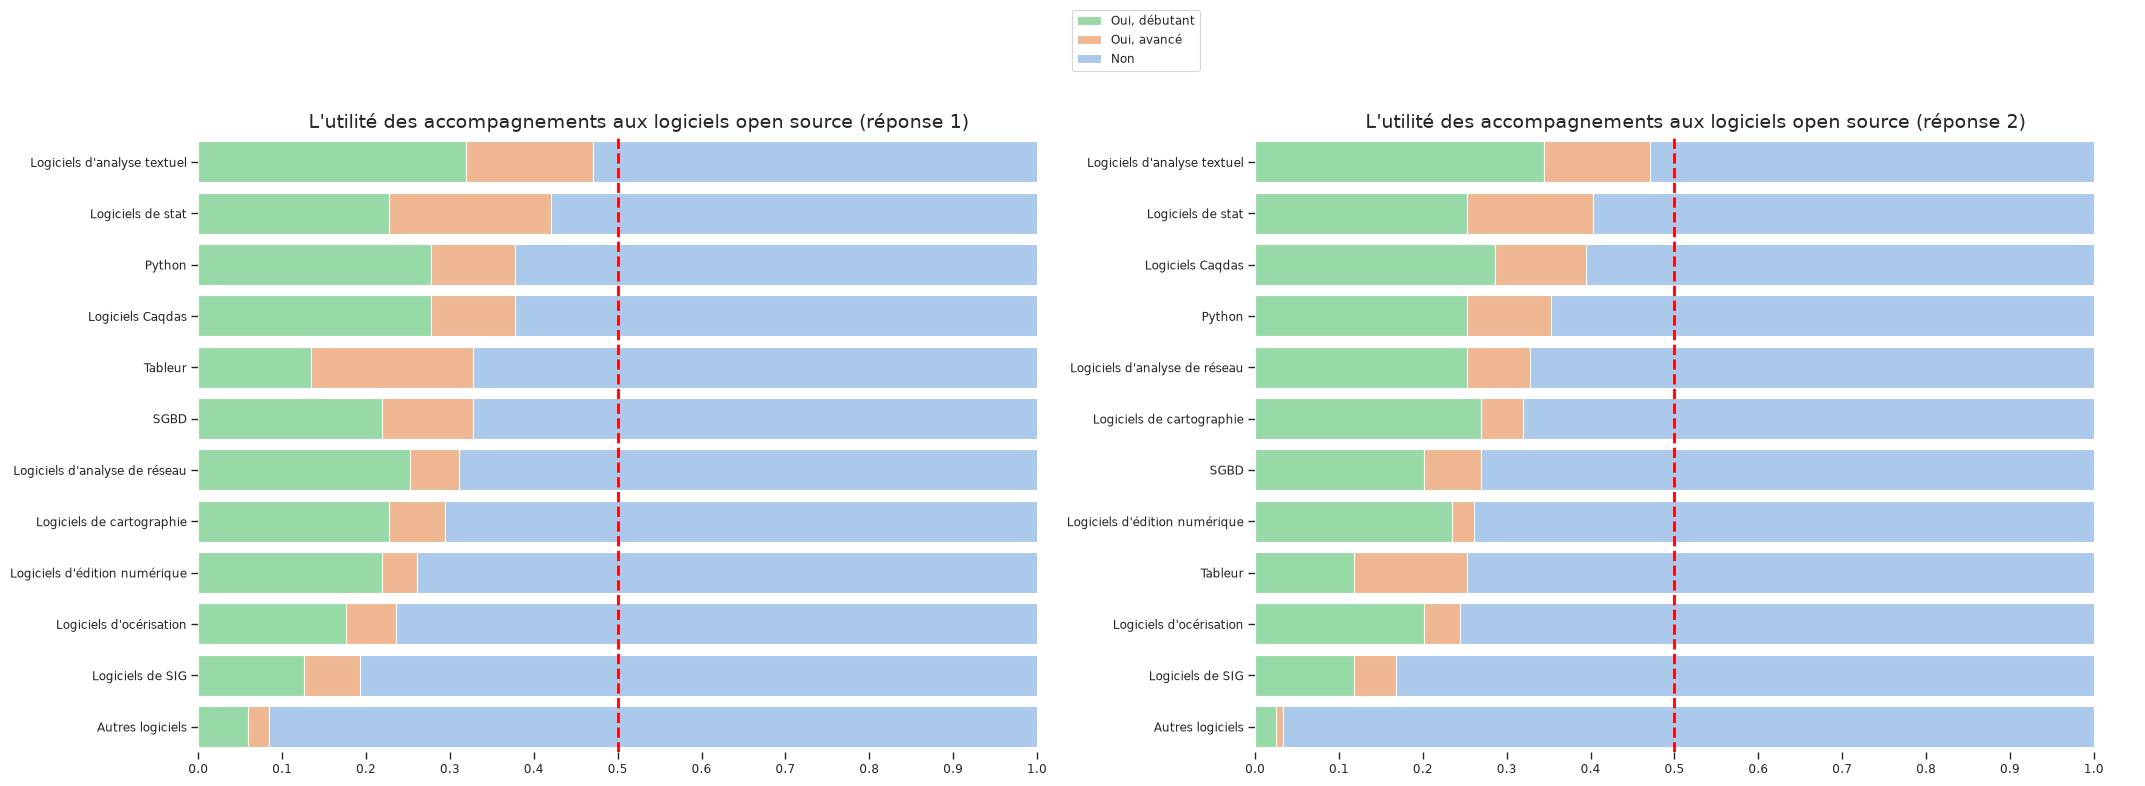

In [58]:
fig, ax = plt.subplots(1,2, figsize=(25,8))

sns.set_theme(style="ticks", context="paper",palette="pastel")

q16_ter["q"] = "q16"
q19_ter["q"] = "q19"
q16_19 = pd.concat([q16_ter, q19_ter])

for n, col in enumerate(["q16", "q19"]):
    q_data= q16_19.loc[q16_19.q==col]
    g = sns.barplot(x="cum_sum", y="accomp_name", data=q_data, hue="interet_accomp", dodge = False, ax=ax[n])
    
    titre = f"L'utilité des accompagnements aux logiciels open source (réponse {n+1})"


    ax[n].yaxis.set_label_text("")
    ax[n].xaxis.set_label_text("")
    # set the x-axis ticklabel size
    ax[n].set_xticks(ticks = [x/10 for x in range(11)])
    #ax[n].set_yticks(fontsize=12)
    ax[n].axvline(x=0.5, color="red", linestyle="--", linewidth=2)
    ax[n].set_title(titre.replace("<i>","(").replace("</i>",")"), fontsize=14)
    #ax[n].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
   
    
    sns.despine(left=True, bottom=True)
    ax[n].legend_.remove()

order = [2,1,0]
handles, labels = ax[0].get_legend_handles_labels()
fig.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='center', bbox_to_anchor=(0.5, 1))

plt.savefig(f"./viz/q16_q19_help_outil.png", bbox_inches='tight', dpi = 300)

Les questions concernant les besoins d'accompagnement à différents types de logiciels open source a été posé deux fois :

- question 7, partie "Gestion et traitement des données"
- la question 3 de la partie "Analyse des données".

La comparaison des tris à plat montre que certaines personnes ont répondu différrement. La différence reste néanmoins marginale. Par exemple, la première fois que la question a été posée, 39 personnes ressentaient le besoin d'être accompagné pour utiliser un tableur contre 30 la seconde fois que la question a été posée ({numref}`tableur_comp_1_2`).

```{table} Besoin d'accompagnement pour l'utilisation de tableur: comparaison des réponses 1 et 2
:name: tableur_comp_1_2

| Tableur  |   Réponse 1 |   Réponse 2 |  
|:-------------------|-----:|--------:|
| Non                |   80 |      89 | 
| Oui, avancé        |   23 |      16 | 
| Oui, débutant      |   16 |      14 | 
|Total               |  119 |     119 |
```


Dans l'ensemble, entre un quart et un tiers des répondants estime avoir besoin d'un accompagnement pour les différents logiciels cités ({numref}`help_outil`). Les quatre premier types de logiciel demandés sont :

1. les logiciels d'analyse textuelle. 48% des répondants disent ressentir le besoin d'un accompagnement (35% à un niveau débutant et 13% à un niveau avancé). À noter que les logiciels cités renvoient à des approches et des méthodes d'analyse différentes.
2. les logiciel d'analyse statistique (40%)
3. les logiciels d'analyse de données qualitatives comme Qualcoder (environ 37%)
4. le langage python (environ 35%)

Ensuite, on observe des demandes d'accompagnement pour les logiciels concernant des méthodes, des données ou des langages plus spécifiques comme les outils d'analyse de réseau de cartographie ou de gestion de bases de données. En bas de classement, nous trouvons enfin les logiciels d'océrisation et de système d'information géographique.

Dans le cas des besoins en accompagnement à la prise en main de logiciels propriétaires, 5 "familles" de logiciels étaient proposaient :

- Les tableurs représentés par Excel
- les logiciels de traitements statistiques comme SPSS, Stata, SAS
- les logiciels de traitement des données textuelles avec Atlas.ti
- les systèmes d'information géographique via ArcGis
- les logiciels d'analyse des données qualitative (CAQDAS, Nvivo)

Le taux de personnes exprimant un besoin d'accompagnement est globablement plus faible que pour les outils open source. Excel est l'outil qui obtient le taux le plus élevé : environ 27% des personnes disent ressentir le besoin d'être accompagnées. On retrouve une proportion relativement similaire à celles des outils de tableur en open source. On constate par contre un écart de 20 personnes entre celles qui sont intéressées par un accompagnement aux logiciels CAQDAS open source et Nvivo ({numref}`q20_19_nvivo`).

```{figure} ./viz/q16_q19_help_outil.png
:name: help_outil

Besoin d'accompagnement aux outils open source
```


```{figure} ./viz/9_help_outil_proprio.png
:name: help_outil_proprio

Besoin d'accompagnement aux outils propriétaires
```

Il semblerait donc que les chercheurs de Paris 8 sont d'avantage intéressés par des outils open source plutôt que propriétaires. Il faut toutefois rester prudent sur cette interprétation des écarts observés dans la mesure où ils peuvent être également lié à une fatigue des répondants, ces derniers choisissant "non" par facilité. Il est possible aussi que la question sur les logiciels open source apparaissent plus générale : en répondant "oui je ressens un besoin d'accompagnement à un logiciel d'analyse textuelle", les personnes visent autant un outil en particulier que la méthode en elle-même (indépendamment du logiciel utilisé).

Une manière de valider l'idée d'une plus grande affinité des chercheurs de Paris 8 pour les logiciels libres serait de comparer ces résultats avec ceux du sondage de la DSIN sur le type de suite bureautique (microsoft, google, outils libres) péblicitée par le personnel de l'université.

```{table} Comparaison des besoins en accompagnement à Nvivo et au logiciels CAQDAS open source
:name: q20_19_nvivo

|    |   Non, je ne ressens pas le besoin d'un accompagnement à un outil CAQDAS open source |   je ressens le besoin d'un accompagnement à un outil CAQDAS open source |   Total |
|:--------|------:|------:|------:|
| Non, je ne ressens pas le besoin d'un accompagnement à Nvivo     |    66 |    26 |    92 |
| Oui, je ressens le besoin d'un accompagnement à Nvivo     |     6 |    21 |    27 |
| Total     |    72 |    47 |   119 |
```
              


Enfin, une dizaine répondants ont fait des suggestion d'outils open source ou propriétaires concernant lesquels ils aimeraient être formés. Ces outils s'inscrivent dans les différentes catégories proposées comme "tropy" (analyses de données qualitatives), jamovi (analyse statistique), les bases de données "orientées graphe" (système de gestion de base de données) ou des outils de traitement du son, des textes ou des images.

```{table} Suggestion d'accompagnement à des outils open source ou propriétaire
:name: suggestion_software

| Autres logiciels open source | Autres logiciels propriétaires |
|:-----------------------------|:-------------------------------|
| logiciel d'analyse des gestes, de l'intonation etc.                 | Qualtrics, Jamovi  |
| wikidata                                                            | Photoshop               |
| Logiciel de reconnaissance de texte manuscrits type Transkribus     | Jamovi               |
| modèle linéaire mixte (LMM)                                         |          |
| Bases de données en graphe éventuellement                                                  |        |
| Logiciel de traitement d'entretiens et de vidéos                                           |        |
| Anaconda (python), Tropes...                                                               |    |
| Tropy                                                                                    |  |

```

In [59]:
# COmparaison des fréquences entre les deux séries de questions

for col in df_col.label.loc[(df_col.label.str.contains("q19_"))&(df_col.type=="ordinal")]:
    for name, label in dict_help_outil1.items():  # for name, age in dictionary.iteritems():  (for Python 2.x)
        if label == dict_help_outil2[col]:
            gb_data= grouped_question(df0, column=col, index="q45_clé")
            gb_data2= grouped_question(df0, column=name, index="q45_clé")
            gb_data3 = gb_data2.merge(gb_data.rename(columns={col:name}), on =[name], how = "left")
            gb_data3["diff"] = gb_data3.nb_x - gb_data3.nb_y
           
            print(gb_data3[[name,"diff"]].to_markdown())
            print("------------------------")
            print(gb_data2.to_markdown())
            print("---------------------")
            print(gb_data.to_markdown())
            print("---------------------")
            print("########################")

|    | q16_tableur_help   |   diff |
|---:|:-------------------|-------:|
|  0 | Non                |     -9 |
|  1 | Oui, avancé        |      7 |
|  2 | Oui, débutant      |      2 |
------------------------
|    | q16_tableur_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                |   80 |     119 | 67.2269 |          100 |
|  1 | Oui, avancé        |   23 |     119 | 19.3277 |          100 |
|  2 | Oui, débutant      |   16 |     119 | 13.4454 |          100 |
---------------------
|    | q19_tableur_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                |   89 |     119 | 74.7899 |          100 |
|  1 | Oui, avancé        |   16 |     119 | 13.4454 |          100 |
|  2 | Oui, débutant      |   14 |     119 | 11.7647 |          100 |
---------------------
########################
|    | q16_logiciels_

In [60]:
for x in df0.q19_1_other_software_help.unique():
    print(x)

nan
wikidata, sparql
Bases de données en graphe
logiciel d'analyse de l'intonation et des gestes sur vidéos
​-


### Outils propriétaires

In [61]:
for col in df_col.label.loc[(df_col.label.str.contains("q20_"))&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q20_excel_help   |   nb |   total |    freq |   total_freq |
|---:|:-----------------|-----:|--------:|--------:|-------------:|
|  0 | Non              |   86 |     119 | 72.2689 |          100 |
|  1 | Oui, avancé      |   18 |     119 | 15.1261 |          100 |
|  2 | Oui, débutant    |   15 |     119 | 12.605  |          100 |
|    | q20_sas_help   |   nb |   total |      freq |   total_freq |
|---:|:---------------|-----:|--------:|----------:|-------------:|
|  0 | Non            |  110 |     119 | 92.437    |          100 |
|  1 | Oui, avancé    |    1 |     119 |  0.840336 |          100 |
|  2 | Oui, débutant  |    8 |     119 |  6.72269  |          100 |
|    | q20_spss_help   |   nb |   total |     freq |   total_freq |
|---:|:----------------|-----:|--------:|---------:|-------------:|
|  0 | Non             |  112 |     119 | 94.1176  |          100 |
|  1 | Oui, avancé     |    3 |     119 |  2.52101 |          100 |
|  2 | Oui, débutant   |    4 |     119 |  3.361

In [62]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q20_"))&(df_col.type=="ordinal")]]

['q20_excel_help',
 'q20_sas_help',
 'q20_spss_help',
 'q20_stata_help',
 'q20_nvivo_help',
 'q20_atlasti_help',
 'q20_oxygen_help',
 'q20_arcgis_help',
 'q20_autre_help']

In [63]:
dict_help_outil_proprio = {
    'q20_excel_help':"Excel",
 'q20_sas_help':"SAS",
 'q20_spss_help':"SPSS",
 'q20_stata_help':"STATA",
 'q20_nvivo_help':"Nvivo",
 'q20_atlasti_help':"Atlas.ti",
 'q20_oxygen_help':"Oxygen",
 'q20_arcgis_help':"Arcgis",
 'q20_autre_help':"Autres"}



In [64]:

i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q20_"))&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_help_outil_proprio[col]


    if i == 0:
        q20 = dftmp.copy()
    else:
        q20 = pd.concat([q20, dftmp])


In [65]:
q20_bis = pd.crosstab(q20.accomp_name, q20.interet_accomp, normalize="index").stack().reset_index(name='nb')
q20_ter =  pd.crosstab(q20.accomp_name, q20.interet_accomp, normalize="index")
q20_ter = q20_ter[['Oui, débutant','Oui, avancé','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


In [66]:
q20_ter = q20_ter.merge(q20_bis, on=["accomp_name","interet_accomp"], how = "left")

In [67]:
for x in q20_ter.accomp_name.unique():
    non = q20_ter.nb.loc[(q20_ter.accomp_name==x) & (q20_ter.interet_accomp=="Non")]
    q20_ter.loc[q20_ter.accomp_name==x, "Oui"] = 1- np.sum(non)
q20_ter = q20_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q20_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
17,Excel,Non,1.000000,0.722689,0.277311
16,Excel,"Oui, avancé",0.277311,0.151261,0.277311
15,Excel,"Oui, débutant",0.126050,0.126050,0.277311
14,Nvivo,Non,1.000000,0.773109,0.226891
13,Nvivo,"Oui, avancé",0.226891,0.075630,0.226891
12,Nvivo,"Oui, débutant",0.151261,0.151261,0.226891
2,STATA,Non,1.000000,0.907563,0.092437
1,STATA,"Oui, avancé",0.092437,0.008403,0.092437
0,STATA,"Oui, débutant",0.084034,0.084034,0.092437
23,Atlas.ti,Non,1.000000,0.907563,0.092437


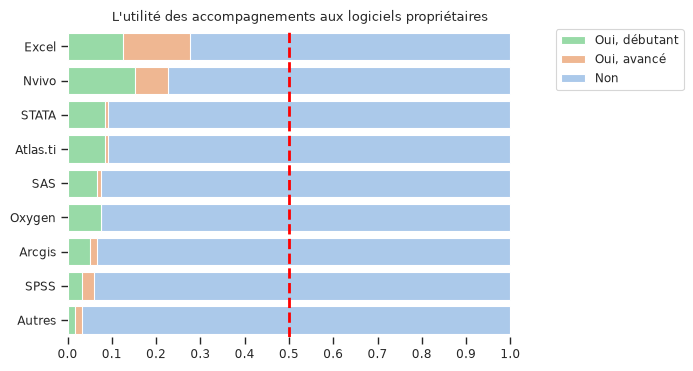

In [68]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(style="ticks", context="paper", palette="pastel")

   
g = sns.barplot(x="cum_sum", y="accomp_name", data=q20_ter, hue="interet_accomp", dodge=False)

titre = "L'utilité des accompagnements aux logiciels propriétaires"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.axvline(x=0.5, color="red", linestyle="--", linewidth=2)
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0]

#add legend to plot


ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/9_help_outil_proprio.png", bbox_inches='tight', dpi = 200)

In [69]:
df0.loc[df0.q20_nvivo_help=="Non", "Nvivo"] ="NON"
df0.loc[df0.q20_nvivo_help!="Non", "Nvivo"] ="Oui"
df0.loc[df0.q19_caqdas_help=="Non", "CAQDAS_os"] ="NON"
df0.loc[df0.q19_caqdas_help!="Non", "CAQDAS_os"] ="Oui"

In [70]:
print(pd.crosstab(df0.Nvivo, df0.CAQDAS_os, normalize=False, margins=True).to_markdown())

| Nvivo   |   NON |   Oui |   All |
|:--------|------:|------:|------:|
| NON     |    66 |    26 |    92 |
| Oui     |     6 |    21 |    27 |
| All     |    72 |    47 |   119 |


In [71]:
for x in df0.q16_1_other_software_help.loc[~df0.q16_1_other_software_help.isna()]:
    print(x)

Logiciel de traitement d'entretiens et de vidéos 
modèle linéaire mixte (LMM)
wikidata
Tropy
Comme je ne connais pas certains de ces logiciels, je ne sais pas s'ils me seraient utiles
Bases de données en graphe éventuellement
logiciel d'analyse des gestes, de l'intonation etc.
Logiciel de reconnaissance de texte manuscrits type Transkribus
Anaconda (python), Tropes...
​-


In [72]:
for x in df0.q19_1_other_software_help.loc[~df0.q19_1_other_software_help.isna()]:
    print(x)

wikidata, sparql
Bases de données en graphe
logiciel d'analyse de l'intonation et des gestes sur vidéos
​-


In [73]:
df01 = df0[["q45_clé","q16_1_other_software_help"]].loc[~df0.q16_1_other_software_help.isna()].merge(df0[["q45_clé","q19_1_other_software_help"]].loc[~df0.q19_1_other_software_help.isna()], on=["q45_clé"], how="left")
df01

,q45_clé,q16_1_other_software_help,q19_1_other_software_help
0,FCCB-GMYA,Logiciel de traitement d'entretiens et de vidéos,NaN
1,9K9T-RVNL,modèle linéaire mixte (LMM),NaN
2,5G5M-BM3L,wikidata,"wikidata, sparql"
3,YL4Q-KQAK,Tropy,NaN
4,ZB5S-ABHN,Comme je ne connais pas certains de ces logici...,NaN
5,DBQD-JQTW,Bases de données en graphe éventuellement,Bases de données en graphe
6,3V5K-8FEA,"logiciel d'analyse des gestes, de l'intonation...",logiciel d'analyse de l'intonation et des gest...
7,82N2-HDNU,Logiciel de reconnaissance de texte manuscrits...,NaN
8,X48K-M3K4,"Anaconda (python), Tropes...",NaN
9,32TW-JLY5,​-,​-


In [74]:
for x in df0.q20_1_other_closed_software_help.loc[~df0.q20_1_other_closed_software_help.isna()]:
    print(x)

Photoshop 
Jamovi : c'est ce logiciel qu'on utilise avec les étudiants car il est gratuit et très facile à utiliser. Il propose de nombreux modules pour lesquels ils seraient intéressant d'être formé afin d'améliorer le niveau de notre expertise par rapport au logiciel
Qualtrics, Jamovi
​-


In [75]:
print(df0[["q45_clé","q16_1_other_software_help"]].loc[~df0.q16_1_other_software_help.isna()].merge(df0[["q45_clé", "q20_1_other_closed_software_help"]].loc[~df0.q20_1_other_closed_software_help.isna()], on =["q45_clé"], how="outer").drop(columns=["q45_clé"]).to_markdown(index=False))

| q16_1_other_software_help                                                                  | q20_1_other_closed_software_help                                                                                                                                                                                                                                   |
|:-------------------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| ​-                                                                                          | ​-                                                                                                                                                                                              

### Services à développer

In [76]:
for col in df_col.label.loc[(df_col.label.str.contains("q22_"))&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q22_postes_info   |   nb |   total |    freq |   total_freq |
|---:|:------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile    |   42 |     119 | 35.2941 |          100 |
|  1 | Oui, plutôt utile |   50 |     119 | 42.0168 |          100 |
|  2 | Oui, très utile   |   27 |     119 | 22.6891 |          100 |
|    | q22_ressources_doc   |   nb |   total |    freq |   total_freq |
|---:|:---------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile       |   19 |     119 | 15.9664 |          100 |
|  1 | Oui, plutôt utile    |   62 |     119 | 52.1008 |          100 |
|  2 | Oui, très utile      |   38 |     119 | 31.9328 |          100 |
|    | q22_working_spaces   |   nb |   total |    freq |   total_freq |
|---:|:---------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile       |   20 |     119 | 16.8067 |          100 |
|  1 | Oui, plutôt utile    |   54 |     119 | 45.3782 |          100 |
|  2 | 

In [77]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q22_"))&(df_col.type=="ordinal")]]

['q22_postes_info',
 'q22_ressources_doc',
 'q22_working_spaces',
 'q22_permanences',
 'q22_sdbox_casd']

In [78]:
dict_services_utiles = {
    'q22_postes_info':"Postes informatiques",
 'q22_ressources_doc':"Ressources documentaires",
 'q22_working_spaces':"Espaces de travail",
 'q22_permanences':"Permanences d'accueil",
 'q22_sdbox_casd':"Accès SdBox et CASD"}



In [79]:
i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q22_"))&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_services_utiles[col]


    if i == 0:
        q22 = dftmp.copy()
    else:
        q22 = pd.concat([q22, dftmp])

In [80]:
q22_bis = pd.crosstab(q22.accomp_name, q22.interet_accomp, normalize="index").stack().reset_index(name='nb')
q22_ter =  pd.crosstab(q22.accomp_name, q22.interet_accomp, normalize="index")
q22_ter = q22_ter[['Oui, plutôt utile','Oui, très utile','Non, pas utile']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


In [81]:
q22_ter = q22_ter.merge(q22_bis, on=["accomp_name","interet_accomp"], how = "left")

In [82]:
q22_ter

,accomp_name,interet_accomp,cum_sum,nb
0,Ressources documentaires,"Oui, très utile",0.840336,0.319328
1,Ressources documentaires,"Oui, plutôt utile",0.521008,0.521008
2,Ressources documentaires,"Non, pas utile",1.000000,0.159664
3,Postes informatiques,"Oui, très utile",0.647059,0.226891
4,Postes informatiques,"Oui, plutôt utile",0.420168,0.420168
5,Postes informatiques,"Non, pas utile",1.000000,0.352941
6,Permanences d'accueil,"Oui, très utile",0.806723,0.411765
7,Permanences d'accueil,"Oui, plutôt utile",0.394958,0.394958
8,Permanences d'accueil,"Non, pas utile",1.000000,0.193277
9,Espaces de travail,"Oui, très utile",0.831933,0.378151


In [83]:
for x in q22_ter.accomp_name.unique():
    non = q22_ter.nb.loc[(q22_ter.accomp_name==x) & (q22_ter.interet_accomp=="Non, pas utile")]
    q22_ter.loc[q22_ter.accomp_name==x, "Oui"] = 1- np.sum(non)
q22_ter = q22_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q22_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
2,Ressources documentaires,"Non, pas utile",1.000000,0.159664,0.840336
0,Ressources documentaires,"Oui, très utile",0.840336,0.319328,0.840336
1,Ressources documentaires,"Oui, plutôt utile",0.521008,0.521008,0.840336
11,Espaces de travail,"Non, pas utile",1.000000,0.168067,0.831933
9,Espaces de travail,"Oui, très utile",0.831933,0.378151,0.831933
10,Espaces de travail,"Oui, plutôt utile",0.453782,0.453782,0.831933
8,Permanences d'accueil,"Non, pas utile",1.000000,0.193277,0.806723
6,Permanences d'accueil,"Oui, très utile",0.806723,0.411765,0.806723
7,Permanences d'accueil,"Oui, plutôt utile",0.394958,0.394958,0.806723
5,Postes informatiques,"Non, pas utile",1.000000,0.352941,0.647059


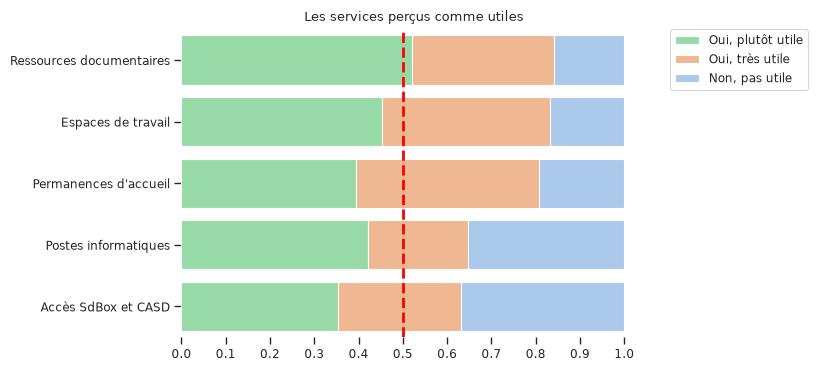

In [84]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(style="ticks", context="paper", palette="pastel")

   
g = sns.barplot(x="cum_sum", y="accomp_name", data=q22_ter, hue="interet_accomp", dodge=False)

titre = "Les services perçus comme utiles"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.axvline(x=0.5, color="red", linestyle="--", linewidth=2)
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))

handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0]

#add legend to plot
#plt.legend() 
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/11_ressources.png", bbox_inches='tight', dpi = 200)

In [85]:
for x in df0.q23_other_service_univ.loc[~df0.q23_other_service_univ.isna()]:
    print("####\n",x)
    

####
 Non 
####
 DE quoi déposer et échanges des données en toute confidentialité et selon les règles imposées par le CNRS notamment
####
 je n' y ai pas suffisamment songé
####
 Certaines université américaines ont des partenariats avec des éditeurs, qui leur permet de valoriser leurs travaux en publiant gratuitement en open access. Pourrait-on avoir ce service ? 
####
 service dans les labos
####
 non
####
 Je ne connais pas le CASD
####
 Apprendre à coder avec l'IA sans devenir soi-même développeur : donc un accès personnalisé à des développeurs (notamment en Python), comme une permanence d'accueil à créneaux fixes
####
 je ne sais pas
####
 Quand je parle de documentation je parle d'ouvrages pour la recherche la bibliothèque étant très loin d'être au niveau sur cet aspect même si elle a un bon.fonds pour la formation... idem pour les salles de réunion ou de travail il y a eu un espace avanius avons b
####
 La possibilité de créer des accès wifi pour les stagiaires et les nouveaux c

Enfin, les services à développer proposés dans le questionnaire ont rencontré un plébiscite dans la mesure où la majorité des personnes les considèrent comme utiles. Le service ayant le moins de succès concerne l'accès à une SD-Box et au CASD (Centre d'accès sécurisé aux données). Près de 63% le jugent utile contre 84% pour les ressources documentaires ou 80% pour les permanences d'accueil. Parmi les 44 personnes non-intéressées par ce dernier service (36%), il est possible qu'une partie d'entre elles ne connaissent pas les services du CASD et la "SD-Box".

> La SD-BOX "La SD-Box est le seul moyen d’accès à l’infrastructure centrale du CASD et à l’environnement de travail de l’utilisateur. C’est un dispositif technique conçu et mis au point par le CASD pour répondre aux besoins et contraintes des utilisateurs et déposants de données".

```{figure} ./viz/11_ressources.png
:name: 11_service_to_develop

Les services à développer
```


Par ailleurs, une quinzaine de personnes ont répondu à la question ouverte : "d'autres services vous paraitraient-ils utiles ?". Plusieurs réponse portent sur les ressources documentaires de la bibliothèque qu'ils jugent "pauvres" au regard d'autre centres ou davantage orientées vers la formation que la recherche.

> "Quand je parle de documentation je parle d'ouvrages pour la recherche la bibliothèque étant très loin d'être au niveau sur cet aspect même si elle a un bon.fonds pour la formation."

> "Il est certain que les ressources documentaires de la bibliothèque sont très pauvres en ce qui concerne la recherche et ne peuvent être utilisées, à mon sens, par des chercheurs d'aujourd'hui."

Les autres commentaires portent sur l'accès à des bureaux nominatifs et équipés informatiquement, "la possibilité de créer des accès wifi pour les stagiaires et les nouveaux collègues dans un délai raisonnable", le développement de services liés à la sécurité des données (accès à un serveur chiffré et des lieux de stockages sécurisés) ou de formation sur l'éthique de la recherche.

> "une formation des chercheurs à des obligations/engagements éthiques ; le comité d'éthique de P8 est récent mais son existence est peu connu ;"

